In [1]:
%pip install import-ipynb

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import import_ipynb
from full_eda_helper_yeni import EDAHelper

In [3]:
helper = EDAHelper.from_csv('insurance.csv')

In [4]:
helper.quick_overview()

--- Şekil (satır, sütun) ---
(1338, 7)

--- Sütun tipleri ---
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

--- İlk satırlar ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Son satırlar ---


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



--- Bilgi (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 255.2 KB


In [5]:
# veri setimizde 1338 satır 7 sütundan oluşur. Hedef değişkenimiz chargesdir ve sayısal olduğu için bu regresyon problemidir.

In [6]:
helper.numeric_summary()

Sayısal değişken özeti:


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [7]:
# 4 tane sayısal sütunumuz vardır.

In [8]:
helper.categorical_summary()


Sütun: sex
Benzersiz değer sayısı: 2


,count
sex,
male,676
female,662



Sütun: smoker
Benzersiz değer sayısı: 2


,count
smoker,
no,1064
yes,274



Sütun: region
Benzersiz değer sayısı: 4


,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [9]:
# 3 tane kategorik sütunumuz vardır.

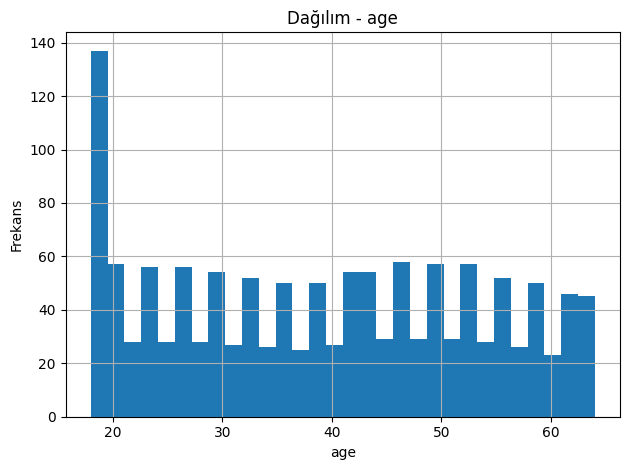

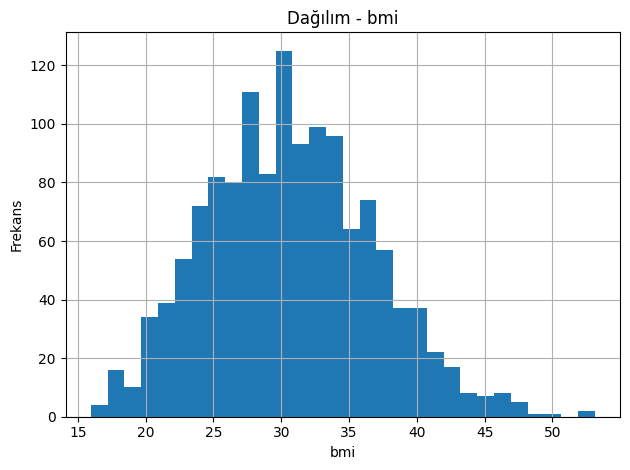

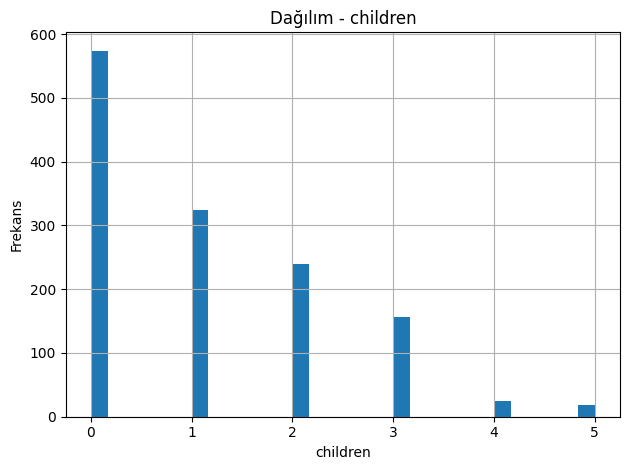

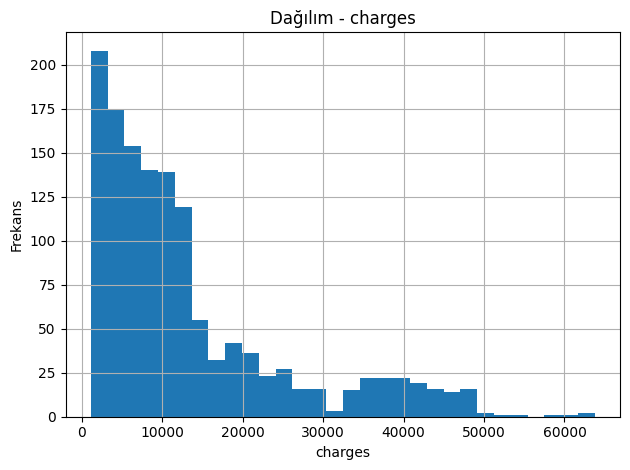

In [10]:
helper.plot_histograms()

In [11]:
# age ve bmi normal dağılmıştır . charges ve children sağa çarpık dağılmıştır.

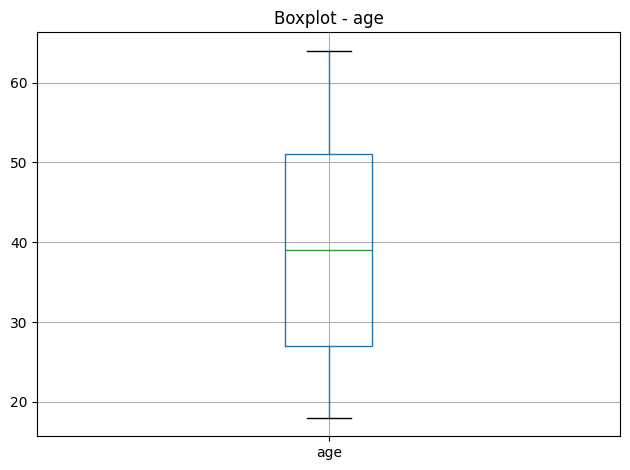

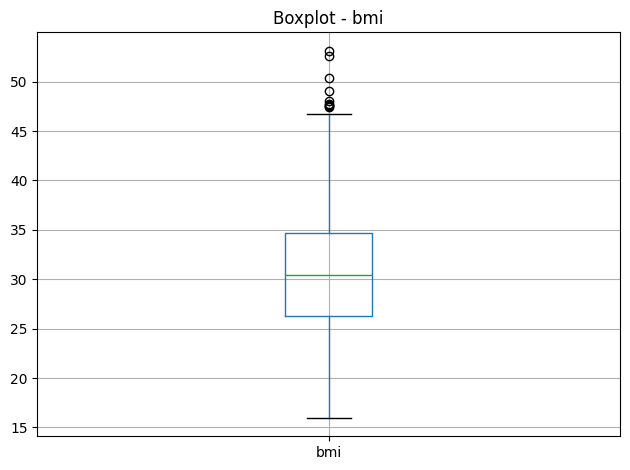

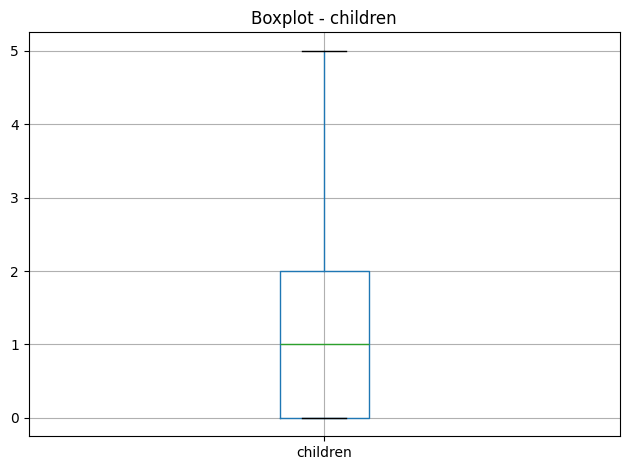

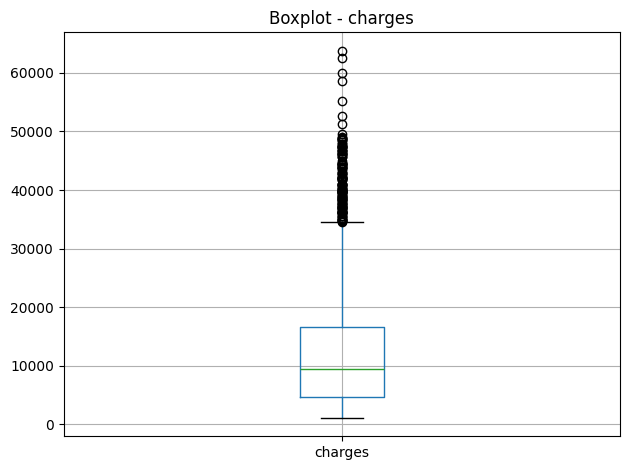

In [28]:
helper.plot_boxplots()

In [12]:
helper.missing_values_report()

Eksik değer raporu:


,missing_count,missing_ratio_%
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


,missing_count,missing_ratio_%
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


In [13]:
helper.outlier_report_all()

Tüm sayısal sütunlar için outlier raporu:


,column,outlier_count,outlier_ratio_%,lower_bound,upper_bound
3,charges,139,10.388640,-13109.150897,34489.350562
1,bmi,9,0.672646,13.700000,47.290000
0,age,0,0.000000,-9.000000,87.000000
2,children,0,0.000000,-3.000000,5.000000


,column,outlier_count,outlier_ratio_%,lower_bound,upper_bound
3,charges,139,10.388640,-13109.150897,34489.350562
1,bmi,9,0.672646,13.700000,47.290000
0,age,0,0.000000,-9.000000,87.000000
2,children,0,0.000000,-3.000000,5.000000


Korelasyon matrisi:


,age,bmi,children,charges
age,1.00,0.11,0.04,0.30
bmi,0.11,1.00,0.01,0.20
children,0.04,0.01,1.00,0.07
charges,0.30,0.20,0.07,1.00


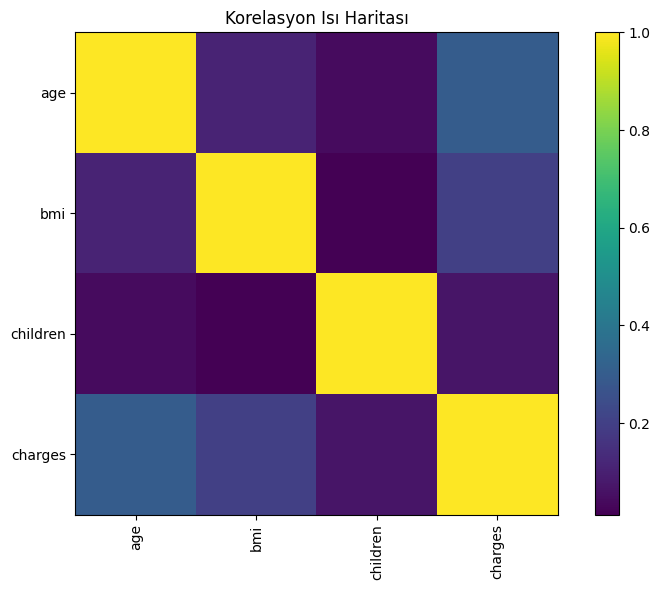

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [14]:
helper.plot_correlation_heatmap()

In [15]:
cat_cols = helper.df.select_dtypes(include=['object', 'category']).columns.tolist()
for cat in cat_cols:
    helper.one_hot_encode(cat)

One-Hot Encoding uygulandı: sex
One-Hot Encoding uygulandı: smoker
One-Hot Encoding uygulandı: region


In [16]:
helper.quick_overview()

--- Şekil (satır, sütun) ---
(1338, 12)

--- Sütun tipleri ---
age                   int64
bmi                 float64
children              int64
charges             float64
sex_female             bool
sex_male               bool
smoker_no              bool
smoker_yes             bool
region_northeast       bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

--- İlk satırlar ---


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False



--- Son satırlar ---


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
1333,50,30.97,3,10600.5483,False,True,True,False,False,True,False,False
1334,18,31.92,0,2205.9808,True,False,True,False,True,False,False,False
1335,18,36.85,0,1629.8335,True,False,True,False,False,False,True,False
1336,21,25.80,0,2007.9450,True,False,True,False,False,False,False,True
1337,61,29.07,0,29141.3603,True,False,False,True,False,True,False,False



--- Bilgi (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_female        1338 non-null   bool   
 5   sex_male          1338 non-null   bool   
 6   smoker_no         1338 non-null   bool   
 7   smoker_yes        1338 non-null   bool   
 8   region_northeast  1338 non-null   bool   
 9   region_northwest  1338 non-null   bool   
 10  region_southeast  1338 non-null   bool   
 11  region_southwest  1338 non-null   bool   
dtypes: bool(8), float64(2), int64(2)
memory usage: 52.4 KB


In [17]:
#Feature Enginerring 

In [18]:
df = helper.df

In [19]:
import numpy as np

def feature_engineering_insurance_ohe(df):
    df = df.copy()

    # =========================
    # 1️⃣ TARGET
    # =========================
    if 'charges' in df.columns:
        df['charges_log'] = np.log1p(df['charges'])

    # =========================
    # 2️⃣ BMI FEATURES
    # =========================
    if 'bmi' in df.columns:
        df['is_obese'] = (df['bmi'] >= 30).astype(int)
        df['bmi_squared'] = df['bmi'] ** 2

    # =========================
    # 3️⃣ SMOKER INTERACTIONS (OHE UYUMLU)
    # =========================
    if 'smoker_yes' in df.columns:
        df['smoker_bmi'] = df['bmi'] * df['smoker_yes']
        df['smoker_age'] = df['age'] * df['smoker_yes']

    # =========================
    # 4️⃣ CHILDREN
    # =========================
    if 'children' in df.columns:
        df['has_children'] = (df['children'] > 0).astype(int)
        df['many_children'] = (df['children'] >= 3).astype(int)

    # =========================
    # 5️⃣ AGE
    # =========================
    if 'age' in df.columns:
        df['age_squared'] = df['age'] ** 2

    # =========================
    # 6️⃣ REGION FLAG (ÖZEL)
    # =========================
    if 'region_southeast' in df.columns:
        df['is_southeast'] = df['region_southeast']

    # =========================
    # 7️⃣ RATIO FEATURES
    # =========================
    if 'bmi' in df.columns and 'age' in df.columns:
        df['bmi_per_age'] = df['bmi'] / df['age']

    if 'children' in df.columns and 'age' in df.columns:
        df['children_per_age'] = df['children'] / df['age']

    return df


In [20]:
df.columns


Index(['age', 'bmi', 'children', 'charges', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [21]:
df_fe = feature_engineering_insurance_ohe(df)

In [22]:
X = df_fe.drop(columns=['charges', 'charges_log'])
y = df_fe['charges_log']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [24]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)


In [25]:
xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [26]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = xgb_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 Score: {r2:.4f}")
print(f"RMSE (log scale): {rmse:.4f}")


R2 Score: 0.8449
RMSE (log scale): 0.3733


In [27]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(10)


,feature,importance
6,smoker_yes,0.300306
5,smoker_no,0.204495
13,smoker_bmi,0.197979
11,is_obese,0.067193
0,age,0.052301
17,age_squared,0.041591
15,has_children,0.029346
2,children,0.017168
7,region_northeast,0.010655
4,sex_male,0.008944
